In [1]:
import pandas as pd
import numpy as np

# Load cleaned dataset
file_path = r"E:\file_main\Major_1\fauna-forecast\data\cleaned\bison_population_cleaned.csv"
df = pd.read_csv(file_path, parse_dates=["Year"], index_col="Year")

# Use the 'Smoothed' column if available, else fallback to 'Population'
target_col = 'Smoothed' if 'Smoothed' in df.columns else 'Population'
series = df[target_col].dropna()

print("Dataset head:\n", series.head())


Dataset head:
 Year
1802-01-01    5.866667e+07
1803-01-01    5.800000e+07
1804-01-01    5.733333e+07
1805-01-01    5.666667e+07
1806-01-01    5.600000e+07
Name: Smoothed, dtype: float64


In [2]:
# Function to create lag features
def create_lag_features(series, n_lags=3):
    df_lags = pd.DataFrame()
    for lag in range(1, n_lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    df_lags['target'] = series.values
    df_lags = df_lags.dropna()
    return df_lags

n_lags = 3  # you can tune this
supervised_df = create_lag_features(series, n_lags)
print("Supervised DataFrame head:\n", supervised_df.head())


Supervised DataFrame head:
                    lag_1         lag_2         lag_3        target
Year                                                              
1805-01-01  5.733333e+07  5.800000e+07  5.866667e+07  5.666667e+07
1806-01-01  5.666667e+07  5.733333e+07  5.800000e+07  5.600000e+07
1807-01-01  5.600000e+07  5.666667e+07  5.733333e+07  5.533333e+07
1808-01-01  5.533333e+07  5.600000e+07  5.666667e+07  5.466667e+07
1809-01-01  5.466667e+07  5.533333e+07  5.600000e+07  5.400000e+07


In [3]:
from sklearn.model_selection import train_test_split

X = supervised_df.drop('target', axis=1).values
y = supervised_df['target'].values

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 168 Test size: 43


In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create SVR pipeline with scaling
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
)

# Fit model
svr_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=100, gamma=0.1))])

SVR Evaluation Metrics:
MAE: 81276.14
RMSE: 143624.05
MAPE: 53.68%


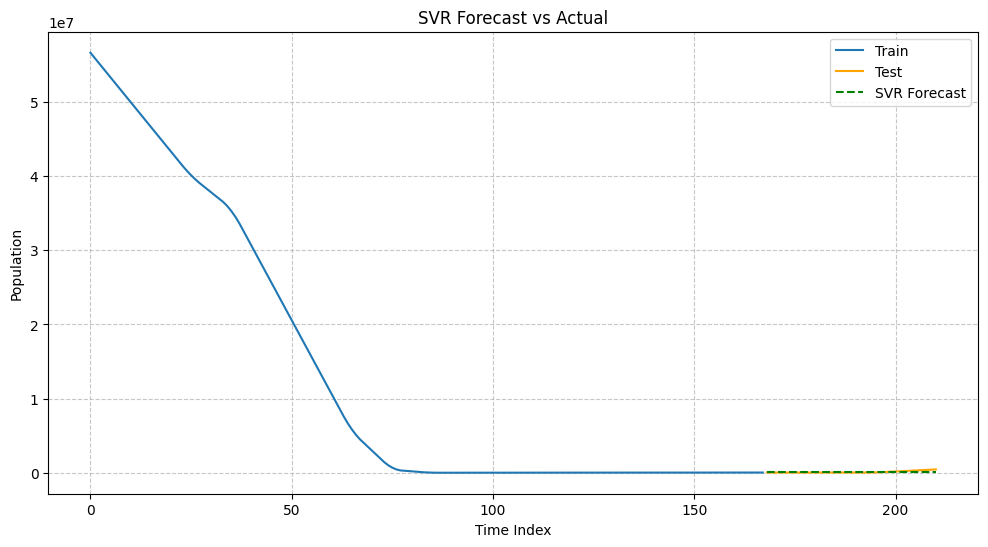

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Predict test set
y_pred = svr_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"SVR Evaluation Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(len(y_train)), y_train, label="Train")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test", color="orange")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_pred, label="SVR Forecast", color="green", linestyle="--")
plt.title("SVR Forecast vs Actual")
plt.xlabel("Time Index")
plt.ylabel("Population")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()
